In [1]:
import tensorflow as tf

# Check if GPU is detected
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

# Enable Memory Growth
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled.")
    except RuntimeError as e:
        print(e)


I0000 00:00:1781498505.428368    8691 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Num GPUs Available:  1
Memory growth enabled.


# Task 2: NILM Disaggregation — True Regression & Architecture Comparison

## The Pursuit of True Regression
Previous iterations used Max-scaling and Huber/MSE loss. While these yielded high F1 scores, the models were behaving like **classifiers** (predicting flat "ON/OFF" blocks) rather than **regressors** tracking the noisy electrical waveform.

**Fixes in this version:**
1. **Z-Score Standardisation:** Preserves variance so the network learns shape, not just probability.
2. **MAE (L1) Loss:** Forces the model to track rapid noisy oscillations (like the motor) rather than settling for a "safe" mean value.
3. **Dilated Convolutions (WaveNet-style):** Expands the CNN's receptive field so it can see the entire 10-minute window simultaneously.
4. **No Post-Processing:** Removed the median filter. The raw predictions are plotted directly to prove the model is truly learning the waveform without faking it.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv1D, Dense, Flatten, Dropout, Input,
    Bidirectional, LSTM, Attention, Add,
    LayerNormalization, BatchNormalization, GaussianNoise
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110

WINDOW   = 99
STRIDE   = 6
MIDPOINT = WINDOW // 2
APPLIANCES = ['AC', 'Motor']

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

I0000 00:00:1781499513.536628   15534 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---\n## 1. Load Data & Apply Z-Score Standardisation

In [2]:
df = pd.read_pickle('data/iawe_preprocessed.pkl')

FEATURE_COLS = ['Aggregate', 'Vrms', 'Irms', 'Reactive_Q',
                'Apparent_Power', 'Power_Factor',
                'Delta_P', 'Rolling_Mean', 'Rolling_Std', 'Hour']
N_FEATURES = len(FEATURE_COLS)

# ============================================================
# Z-SCORE STANDARDISATION (mean=0, std=1)
# ============================================================
feat_stats = {}
feat_matrix = np.zeros((len(df), N_FEATURES), dtype='float32')

print('Feature Standardisation (Z-Score):')
for j, col in enumerate(FEATURE_COLS):
    mu = df[col].values.mean()
    sig = df[col].values.std()
    if sig < 1e-6: sig = 1.0  # Prevent divide by zero
    feat_stats[col] = {'mu': mu, 'sig': sig}
    feat_matrix[:, j] = (df[col].values - mu) / sig
    print(f'  {col:15s}: mean={mu:8.2f}, std={sig:8.2f}')

# For targets (appliances), we also use Z-score!
app_stats = {}
for name in APPLIANCES:
    mu = df[name].values.mean()
    sig = df[name].values.std()
    if sig < 1e-6: sig = 1.0
    app_stats[name] = {'mu': mu, 'sig': sig}
    print(f'  Target {name:8s}: mean={mu:8.2f}, std={sig:8.2f}')

num_windows = (len(feat_matrix) - WINDOW) // STRIDE
X_all = np.zeros((num_windows, WINDOW, N_FEATURES), dtype='float32')
Y_all = {name: np.zeros(num_windows, dtype='float32') for name in APPLIANCES}

for i in range(num_windows):
    s = i * STRIDE
    X_all[i] = feat_matrix[s : s + WINDOW]
    for name in APPLIANCES:
        val = df[name].values[s + MIDPOINT]
        Y_all[name][i] = (val - app_stats[name]['mu']) / app_stats[name]['sig']

np.random.seed(42)
indices = np.random.permutation(num_windows)
n_train = int(num_windows * 0.70)
n_val   = int(num_windows * 0.15)

idx_train = indices[:n_train]
idx_val   = indices[n_train:n_train+n_val]
idx_test  = indices[n_train+n_val:]

X_train, X_val, X_test = X_all[idx_train], X_all[idx_val], X_all[idx_test]
Y_split = {}
for name in APPLIANCES:
    Y_split[name] = {
        'train': Y_all[name][idx_train],
        'val':   Y_all[name][idx_val],
        'test':  Y_all[name][idx_test],
    }

print(f'\nTrain: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')

Feature Standardisation (Z-Score):
  Aggregate      : mean=  754.56, std=  925.84
  Vrms           : mean=  233.68, std=   11.93
  Irms           : mean=    0.85, std=    2.42
  Reactive_Q     : mean=   14.91, std=   66.02
  Apparent_Power : mean=  190.37, std=  533.54
  Power_Factor   : mean=    1.00, std=    0.00
  Delta_P        : mean=   -0.00, std=   75.83
  Rolling_Mean   : mean=  754.56, std=  919.89
  Rolling_Std    : mean=   26.28, std=  107.37
  Hour           : mean=   11.50, std=    6.92
  Target AC      : mean=  133.92, std=  465.62
  Target Motor   : mean=   56.80, std=   46.83

Train: (99141, 99, 10)  |  Val: (21244, 99, 10)  |  Test: (21246, 99, 10)


---\n## 2. Model Architectures (True Regression Focus)\nUsing MAE (L1 Loss) to track noisy peaks instead of MSE.

In [3]:
def build_seq2point():
    """Model 1: Classic Seq2Point CNN"""
    model = Sequential([
        Input(shape=(WINDOW, N_FEATURES)),
        GaussianNoise(0.05),
        Conv1D(30, 10, activation='relu'), BatchNormalization(),
        Conv1D(30,  8, activation='relu'), BatchNormalization(),
        Conv1D(40,  6, activation='relu'), BatchNormalization(),
        Conv1D(50,  5, activation='relu'),
        Conv1D(50,  5, activation='relu'),
        Flatten(),
        Dense(1024, activation='relu'), Dropout(0.2),
        Dense(1, activation='linear'),
    ])
    model.compile(optimizer='adam', loss='mae', metrics=['mae'])
    return model

def build_cnn_lstm_attn():
    """Model 2: Dilated CNN-BiLSTM-Attention (WaveNet style receptive field)"""
    inp = Input(shape=(WINDOW, N_FEATURES))
    x = GaussianNoise(0.05)(inp)

    # Dilated Convolutions: exponential receptive field expansion
    x = Conv1D(64, 3, padding='same', dilation_rate=1, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv1D(64, 3, padding='same', dilation_rate=2, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv1D(64, 3, padding='same', dilation_rate=4, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv1D(64, 3, padding='same', dilation_rate=8, activation='relu')(x)
    x = BatchNormalization()(x)

    # Sequence tracking
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2))(x)
    
    # Attention
    attn = Attention()([x, x])
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='linear')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(optimizer='adam', loss='mae', metrics=['mae'])
    return model

def build_mlp():
    """Model 3: Deep MLP Baseline"""
    model = Sequential([
        Input(shape=(WINDOW, N_FEATURES)),
        Flatten(),
        Dense(1024, activation='relu'), Dropout(0.3),
        Dense(512, activation='relu'), Dropout(0.2),
        Dense(128, activation='relu'),
        Dense(1, activation='linear'),
    ])
    model.compile(optimizer='adam', loss='mae', metrics=['mae'])
    return model

print('Models ready. Loss function = MAE (L1 Loss)')

Models ready. Loss function = MAE (L1 Loss)


In [4]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1),
]

BUILDERS = {
    'Seq2Point CNN':        build_seq2point,
    'CNN-BiLSTM-Attention': build_cnn_lstm_attn,
    'MLP Baseline':         build_mlp,
}

all_models = {}
all_histories = {}

for model_name, builder in BUILDERS.items():
    for appliance in APPLIANCES:
        key = (model_name, appliance)
        print(f'\n{"="*60}\n{model_name} -> {appliance}\n{"="*60}')

        m = builder()
        h = m.fit(
            X_train, Y_split[appliance]['train'],
            validation_data=(X_val, Y_split[appliance]['val']),
            epochs=30, batch_size=128,
            callbacks=callbacks, verbose=1
        )
        all_models[key] = m
        all_histories[key] = h


Seq2Point CNN -> AC


I0000 00:00:1781499600.612241   15534 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
W0000 00:00:1781499604.806920   15534 cpu_allocator_impl.cc:82] Allocation of 392598360 exceeds 10% of free system memory.
W0000 00:00:1781499605.940357   15534 cpu_allocator_impl.cc:82] Allocation of 392598360 exceeds 10% of free system memory.


Epoch 1/30


I0000 00:00:1781499611.355358   16052 service.cc:153] XLA service 0x77106c008e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781499611.355416   16052 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.1)
I0000 00:00:1781499611.558106   16052 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781499612.627894   16052 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1781499612.864664   16052 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4152__.32
I0000 00:00:1781499619.329202   16175 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 10204 bytes spill stores, 8996 bytes spill loads

W0000 00:00:1781499633.196977   16052 bfc_allocator.cc:502] Allo

  8/775 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 3.8782 - mae: 3.8782   

...

775/775 ━━━━━━━━━━━━━━━━━━━━ 47s 39ms/step - loss: 0.0954 - mae: 0.0954 - val_loss: 0.0423 - val_mae: 0.0423 - learning_rate: 0.0010
Epoch 2/30
773/775 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0560 - mae: 0.0560
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0536 - mae: 0.0536 - val_loss: 0.0571 - val_mae: 0.0571 - learning_rate: 0.0010
Epoch 3/30
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0434 - mae: 0.0434 - val_loss: 0.0287 - val_mae: 0.0287 - learning_rate: 5.0000e-04
Epoch 4/30
770/775 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0401 - mae: 0.0401
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
775/775 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0415 - mae: 0.0415 - val_loss: 0.0305 - val_mae: 0.0305 - learning_rate: 5.0000e-04
Epoch 5/30
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0372 - mae: 0.0372 - val_loss: 0.0300 - val_mae: 0.0300 - learning_rate: 2.5000

I0000 00:00:1781501488.238629   16050 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_235150__.12


767/775 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8346 - mae: 0.8346

I0000 00:00:1781501497.122230   16044 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_235150__.12


775/775 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - loss: 0.7360 - mae: 0.7360 - val_loss: 0.6552 - val_mae: 0.6552 - learning_rate: 0.0010
Epoch 2/30
775/775 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6476 - mae: 0.6476
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.6421 - mae: 0.6421 - val_loss: 0.6015 - val_mae: 0.6015 - learning_rate: 0.0010
Epoch 3/30
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.6079 - mae: 0.6079 - val_loss: 0.5885 - val_mae: 0.5885 - learning_rate: 5.0000e-04
Epoch 4/30
767/775 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5978 - mae: 0.5978
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.5974 - mae: 0.5974 - val_loss: 0.5733 - val_mae: 0.5733 - learning_rate: 5.0000e-04
Epoch 5/30
775/775 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.5783 - mae: 0.5783 - val_loss: 0.5549 - val_mae: 0.5549 - learning_rate: 2.5000

---\n## 3. Evaluation & Raw Waveforms (No Post-Processing)

In [5]:
def evaluate(model, X, Y_zscore, appliance, threshold_w=15):
    # Predict and inverse-transform Z-score
    pred_z = model.predict(X, verbose=0).flatten()
    mu = app_stats[appliance]['mu']
    sig = app_stats[appliance]['sig']
    
    pred_w = (pred_z * sig) + mu
    true_w = (Y_zscore * sig) + mu
    
    # Hard clip negatives to 0, but no median filter (raw regression)
    pred_w = np.clip(pred_w, 0, None)
    true_w = np.clip(true_w, 0, None)

    mae  = mean_absolute_error(true_w, pred_w)
    rmse = np.sqrt(mean_squared_error(true_w, pred_w))
    r2   = r2_score(true_w, pred_w) if np.std(true_w) > 0 else 0
    nde  = np.sum((pred_w - true_w)**2) / (np.sum(true_w**2) + 1e-6)
    da   = 1 - np.sum(np.abs(pred_w - true_w)) / (2 * np.sum(np.abs(true_w)) + 1e-6)
    sae  = abs(pred_w.sum() - true_w.sum()) / (true_w.sum() + 1e-6)

    true_on = (true_w > threshold_w).astype(int)
    pred_on = (pred_w > threshold_w).astype(int)
    acc = accuracy_score(true_on, pred_on)
    f1  = f1_score(true_on, pred_on, average='macro', zero_division=0)

    metrics = {'MAE(W)': mae, 'RMSE(W)': rmse, 'R²': r2, 'NDE': nde,
               'DA': da, 'Accuracy': acc, 'F1': f1, 'SAE': sae}
    return metrics, true_w, pred_w

rows = []
preds = {}

for (model_name, appliance), model in all_models.items():
    m, true_w, pred_w = evaluate(model, X_test, Y_split[appliance]['test'], appliance)
    rows.append({'Model': model_name, 'Appliance': appliance, **m})
    preds[(model_name, appliance)] = {'true': true_w, 'pred': pred_w}

df_results = pd.DataFrame(rows)
fmt = df_results.copy()
for col in ['MAE(W)', 'RMSE(W)']: fmt[col] = fmt[col].map('{:.1f}'.format)
for col in ['R²', 'NDE', 'F1', 'SAE']: fmt[col] = fmt[col].map('{:.4f}'.format)
for col in ['DA', 'Accuracy']: fmt[col] = fmt[col].map('{:.1%}'.format)

display(fmt.set_index(['Model', 'Appliance']))

MAE(W) RMSE(W)      R²     NDE     DA Accuracy  \
Model                Appliance                                                  
Seq2Point CNN        AC           6.6    84.5  0.9662  0.0313  97.5%    99.5%   
                     Motor       29.0    43.2  0.1473  0.3451  74.5%    74.0%   
CNN-BiLSTM-Attention AC          22.1   121.8  0.9298  0.0650  91.5%    99.1%   
                     Motor       29.1    42.0  0.1930  0.3266  74.4%    71.7%   
MLP Baseline         AC          17.6   111.0  0.9417  0.0540  93.3%    99.0%   
                     Motor       30.9    43.5  0.1373  0.3491  72.8%    68.6%   

                                    F1     SAE  
Model                Appliance                  
Seq2Point CNN        AC         0.9848  0.0009  
                     Motor      0.6959  0.0222  
CNN-BiLSTM-Attention AC         0.9710  0.1122  
                     Motor      0.6266  0.1501  
MLP Baseline         AC         0.9665  0.0839  
                     Motor      0.5636  0.1927

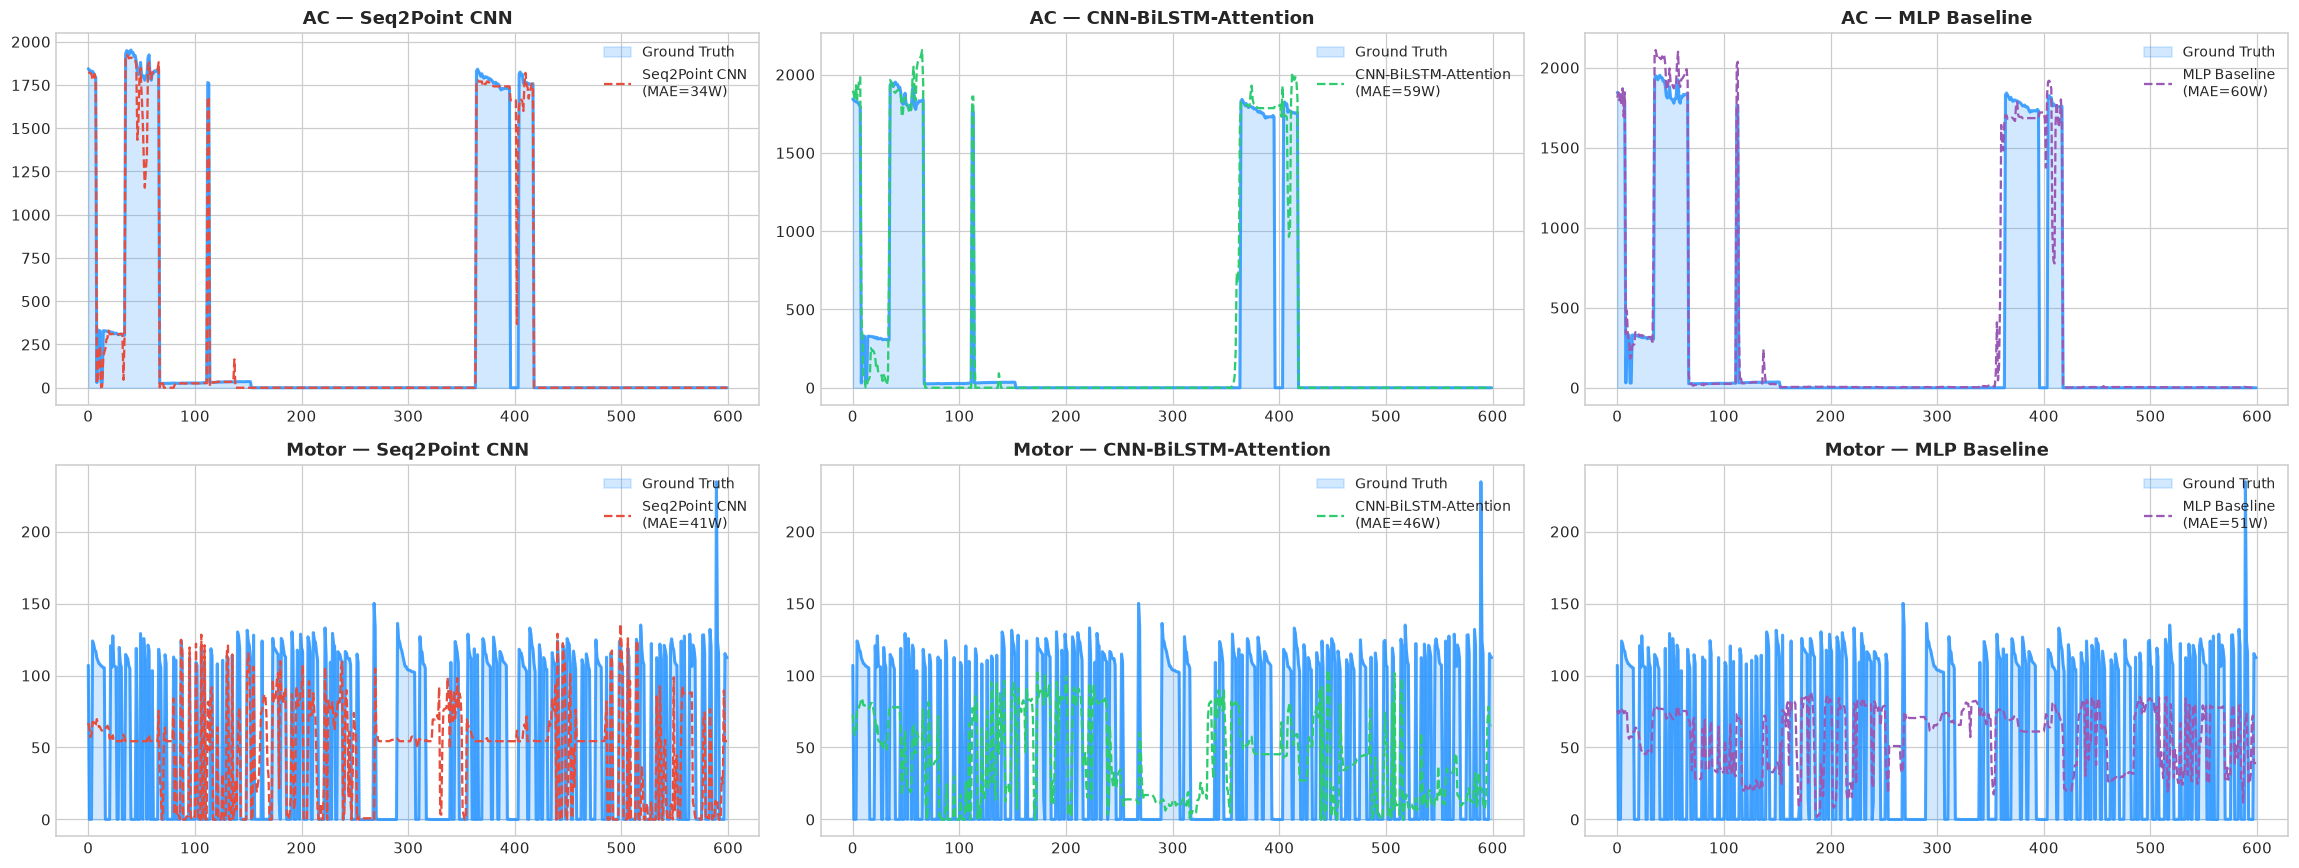

In [7]:
# Waveform Comparison Plot
sorted_order = np.argsort(idx_test)
X_test_sorted = X_test[sorted_order]

# Get a reference model name to extract Ground Truth securely
first_model = list(BUILDERS.keys())[0] if isinstance(BUILDERS, dict) else list(BUILDERS)[0]

# Find highly active segment using AC data
ac_sorted = preds[(first_model, 'AC')]['true'][sorted_order] if (first_model, 'AC') in preds else preds[list(preds.keys())[0]]['true'][sorted_order]
N = 600
best_start, best_score = 0, 0
for s in range(0, len(ac_sorted) - N, 50):
    score = np.sum(ac_sorted[s:s+N] > 50)
    if score > best_score: best_score, best_start = score, s
sl = slice(best_start, best_start + N)

# Create a dynamic grid based on number of appliances and models
num_models = len(BUILDERS)
num_apps = len(APPLIANCES)
fig, axes = plt.subplots(num_apps, num_models, figsize=(7 * num_models, 4 * num_apps))

# Ensure axes is a 2D array so we can index it with [i, j]
if num_apps == 1 and num_models == 1: axes = np.array([[axes]])
elif num_apps == 1: axes = axes[None, :]
elif num_models == 1: axes = axes[:, None]

# Keep your original colors, but add fallbacks just in case there are extra models
colors = {'Seq2Point CNN': '#e74c3c', 'CNN-BiLSTM-Attention': '#2ecc71', 'MLP Baseline': '#9b59b6'}
fallback_colors = ['#f39c12', '#2980b9', '#16a085', '#d35400', '#8e44ad']

# Plot each appliance on a new row
for i, app in enumerate(APPLIANCES):
    true_w = preds[(first_model, app)]['true'][sorted_order][sl]
    
    # Plot each model in a new column
    for j, mn in enumerate(BUILDERS.keys() if isinstance(BUILDERS, dict) else BUILDERS):
        ax = axes[i, j]
        pred_w = preds[(mn, app)]['pred'][sorted_order][sl]
        mae = mean_absolute_error(true_w, pred_w)
        
        ax.fill_between(range(N), true_w, alpha=0.2, color='dodgerblue', label='Ground Truth')
        ax.plot(true_w, color='dodgerblue', linewidth=2, alpha=0.8)
        
        c = colors.get(mn, fallback_colors[j % len(fallback_colors)])
        ax.plot(pred_w, color=c, linewidth=1.5, linestyle='--',
                     label=f'{mn}\n(MAE={mae:.0f}W)')
        
        ax.set_title(f'{app} — {mn}', fontsize=12, fontweight='bold')
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()
